# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡🚀 Protecting Food Industry with the help of ML  📚˚ ༘ ೀ⋆｡ ˚</p>

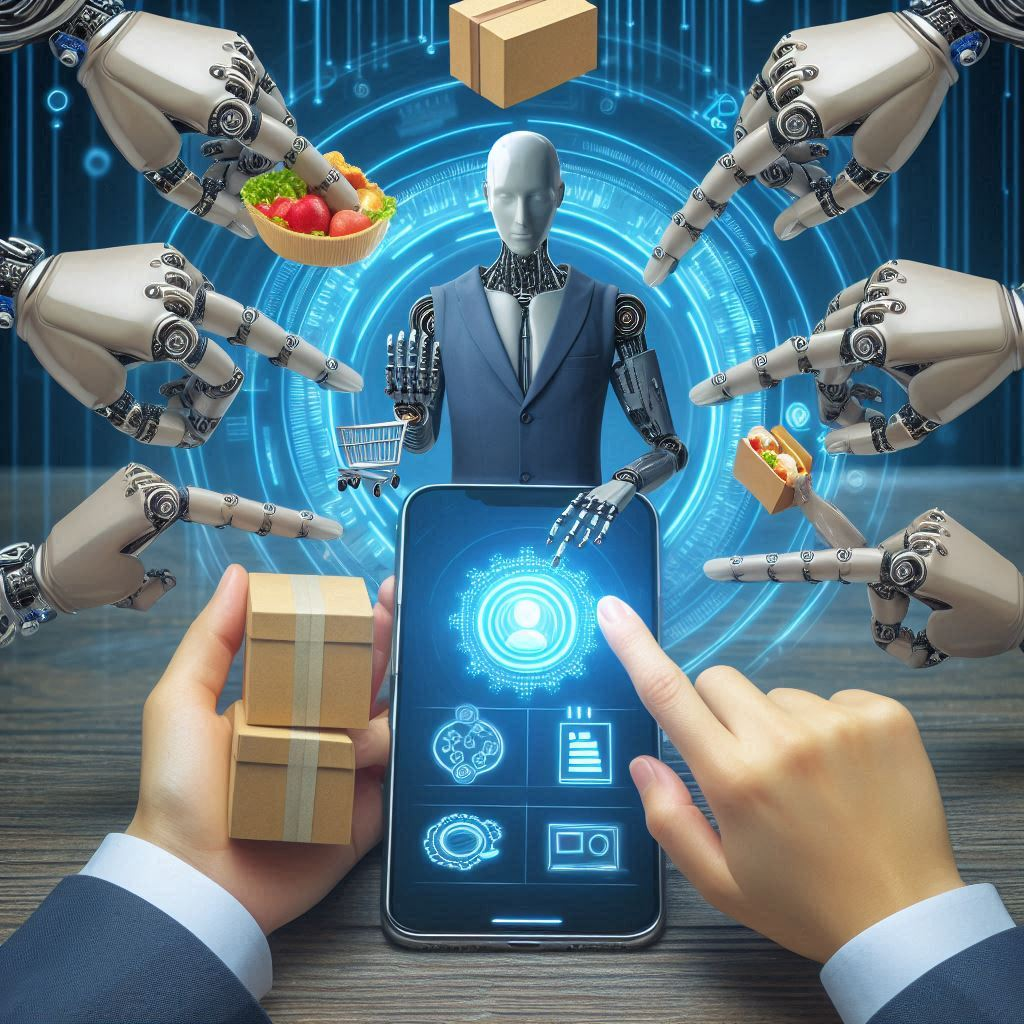

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ About The Auther  ˚ ༘ ೀ⋆｡ ˚</p>

<div style="border: 2px solid #14adc6; padding: 10px; max-width: 1000px; margin: 0 auto;">
    <p>
        "Alone we can do so little; together we can do so much." - Helen Keller 🌟
    </p>
    <p>
        I am <b>Saman Fatima</b>, a passionate data scientist dedicated to mastering machine learning techniques and continually expanding my knowledge base. I believe in the mantra of KeepLearning and KeepSupporting, as I am committed to constant growth and uplifting others in the field. 🚀
    </p>
    <div style="text-align: center;">
        <img src="https://media.licdn.com/dms/image/D4D03AQFAcZhjvE7C0Q/profile-displayphoto-shrink_800_800/0/1714558384812?e=1721260800&v=beta&t=vfqq1fnuYMej7Tpr_MGPhs1c9DuVyJHbzZT0XuacRds" alt="Profile Picture" style="width: 100px; height: 100px; border-radius: 50%; border: 2px solid #14adc6;"><br>
    </div>
    <p>
        You can find more about me on my <a href="https://www.linkedin.com/in/saman-fatima-datascience/" target="_blank">LinkedIn</a>.<br>
        Feel free to connect and reach out for any collaboration or queries! 📊
    </p>
    <p>My skills include:</p>
    <ul style="list-style-type: disc; margin-left: 20px;">
        <li>Data Analysis 📉</li>
        <li>Machine Learning 🤖</li>
        <li>Deep Learning 🧠</li>
        <li>Statistical Modeling 📈</li>
        <li>Data Visualization 📊</li>
    </ul>
    <p> If you find any content helpful, consider giving it an upvote. Your support means a lot! 👍</p>
</div>

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ Importing The Libraries  ˚ ༘ ೀ⋆｡ ˚</p>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from IPython.display import display, HTML
import warnings
from colorama import Fore, Style
from catboost import CatBoostRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint
from lightgbm import LGBMRegressor
import lightgbm as lgb
from math import pi
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore')

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ Loading The Dataset˚ ༘ ೀ⋆｡ ˚</p>

In [2]:
df_tr = pd.read_csv('/kaggle/input/rohlik-orders-forecasting-challenge/train.csv')
df_ts = pd.read_csv('/kaggle/input/rohlik-orders-forecasting-challenge/test.csv')
df_s = pd.read_csv('/kaggle/input/rohlik-orders-forecasting-challenge/solution_example.csv')

In [3]:
df_ts.columns

Index(['warehouse', 'date', 'holiday_name', 'holiday', 'shops_closed',
       'winter_school_holidays', 'school_holidays', 'id'],
      dtype='object')

In [4]:
df_tr.columns

Index(['warehouse', 'date', 'orders', 'holiday_name', 'holiday', 'shutdown',
       'mini_shutdown', 'shops_closed', 'winter_school_holidays',
       'school_holidays', 'blackout', 'mov_change', 'frankfurt_shutdown',
       'precipitation', 'snow', 'user_activity_1', 'user_activity_2', 'id'],
      dtype='object')

## - As we can see that the columns in the train dataset are extra and they dont even exist in the test data so we need to drop them 

In [5]:
columns_to_drop = ['shutdown', 'mini_shutdown','blackout', 'mov_change', 'frankfurt_shutdown',
       'precipitation', 'snow', 'user_activity_1', 'user_activity_2',]
df_tr = df_tr.drop(columns_to_drop, axis=1)


In [6]:
df_ts.columns

Index(['warehouse', 'date', 'holiday_name', 'holiday', 'shops_closed',
       'winter_school_holidays', 'school_holidays', 'id'],
      dtype='object')

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ SneakPeak Of The Data ˚ ༘ ೀ⋆｡ ˚</p>

<span style="font-size: 14px; font-family: Verdana; background-color: #5fa1bc; color: white; border: 2px solid #ccc; padding: 10px; border-radius: 10px; display: inline-block;">
  I've created a convenient function to display detailed information about the dataset with just one click. This function provides essential insights into the dataset's structure, summary statistics, and data types, allowing for a quick understanding of its contents. Feel free to utilize this function in your analysis, but please ensure to give proper reference when using it. Your support and acknowledgment are greatly appreciated!
</span>

In [7]:
def styled_heading(text):
    return f"""
    <p style="
        font-family: 'Amiri'; 
        font-size: 3rem; 
        color: yellow; 
        text-align: center; 
        margin: 0; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); 
        background-color: #5fa1bc; 
        padding: 20px; 
        border-radius: 20px; 
        border: 7px solid yellow; 
        width:95%">
        {text}
    </p>
    """

def print_error(message):
    display(HTML(styled_heading("Error")))
    print(f"An error occurred: {message}")

# Helper function to generate colored horizontal line
def colored_line(color='#323c6a'):
    return ""

def print_dataset_analysis(train_dataset, test_dataset, n_top=5, heading_color='#323c6a', line_color='#323c6a'):
    try:
        # Printing top values
        train_heading = styled_heading(f"🔝 Top {n_top} rows of Training Dataset")
        test_heading = styled_heading(f"🔝 Top {n_top} rows of Test Dataset")

        display(HTML(colored_line(line_color)))
        display(HTML(train_heading))
        display(HTML(colored_line(line_color)))
        display(HTML(train_dataset.head(n_top).to_html()))

        display(HTML(colored_line(line_color)))
        display(HTML(test_heading))
        display(HTML(colored_line(line_color)))
        display(HTML(test_dataset.head(n_top).to_html()))
        
        # Printing dataset summary
        summary_heading = styled_heading("📊 Summary of Dataset")
        display(HTML(colored_line(line_color)))
        display(HTML(summary_heading))
        display(HTML(colored_line(line_color)))
        display(HTML(train_dataset.describe().to_html()))

        # Printing null values
        null_heading = styled_heading("❌ Null Values in Datasets")
        
        train_null_count = train_dataset.isnull().sum()
        test_null_count = test_dataset.isnull().sum()

        display(HTML(colored_line(line_color)))
        display(HTML(null_heading))
        display(HTML(colored_line(line_color)))
        display(HTML("<h3>Training Dataset:</h3>"))
        if train_null_count.sum() == 0:
            display(HTML("<p>No null values in the training dataset.</p>"))
        else:
            display(HTML(train_null_count[train_null_count > 0].to_frame().to_html()))
            display(HTML("<p>These are the null values.</p>"))

        display(HTML("<h3>Test Dataset:</h3>"))
        if test_null_count.sum() == 0:
            display(HTML("<p>No null values in the test dataset.</p>"))
        else:
            display(HTML(test_null_count[test_null_count > 0].to_frame().to_html()))
            display(HTML("<p>These are the null values.</p>"))

        # Printing duplicate values
        duplicate_heading = styled_heading("♻️ Duplicate Values in Datasets")
        
        train_duplicates = train_dataset.duplicated().sum()
        test_duplicates = test_dataset.duplicated().sum()

        display(HTML(colored_line(line_color)))
        display(HTML(duplicate_heading))
        display(HTML(colored_line(line_color)))
        display(HTML("<h3>Training Dataset:</h3>"))
        display(HTML(f"<p>{train_duplicates} duplicate rows</p>"))

        display(HTML("<h3>Test Dataset:</h3>"))
        display(HTML(f"<p>{test_duplicates} duplicate rows</p>"))
        
        # Printing number of rows and columns
        shape_heading = styled_heading("📏 Number of Rows and Columns")
        display(HTML(colored_line(line_color)))
        display(HTML(shape_heading))
        display(HTML(colored_line(line_color)))
        display(HTML("<h3>Training Dataset:</h3>"))
        display(HTML(f"<p>Rows: {train_dataset.shape[0]}, Columns: {train_dataset.shape[1]}</p>"))
        display(HTML("<h3>Test Dataset:</h3>"))
        display(HTML(f"<p>Rows: {test_dataset.shape[0]}, Columns: {test_dataset.shape[1]}</p>"))

    except Exception as e:
        print_error(str(e))

def print_unique_values(test_dataset, heading_color='#323c6a', line_color='#323c6a'):
    try:
        unique_values_heading = styled_heading("🔢 Unique Values in Training Dataset")
        
        display(HTML(colored_line(line_color)))
        display(HTML(unique_values_heading))
        display(HTML(colored_line(line_color)))
        
        unique_values_table = "<table border='1'><tr><th>Column Name</th><th>Data Type</th><th>Unique Values</th></tr>"
        
        for column in test_dataset.columns:
            unique_values = test_dataset[column].unique()[:7]  # Taking at least 7 unique values
            unique_values_str = ', '.join(map(str, unique_values))
            data_type = test_dataset[column].dtype
            unique_values_table += f"<tr><td>{column}</td><td>{data_type}</td><td>{unique_values_str}</td></tr>"
        
        unique_values_table += "</table>"
        display(HTML(unique_values_table))
    
    except Exception as e:
        print_error(str(e))


In [8]:
print_dataset_analysis(df_tr, df_ts)
print_unique_values(df_tr)

,warehouse,date,orders,holiday_name,holiday,shops_closed,winter_school_holidays,school_holidays,id
0,Prague_1,2020-12-05,6895.0,NaN,0,0,0,0,Prague_1_2020-12-05
1,Prague_1,2020-12-06,6584.0,NaN,0,0,0,0,Prague_1_2020-12-06
2,Prague_1,2020-12-07,7030.0,NaN,0,0,0,0,Prague_1_2020-12-07
3,Prague_1,2020-12-08,6550.0,NaN,0,0,0,0,Prague_1_2020-12-08
4,Prague_1,2020-12-09,6910.0,NaN,0,0,0,0,Prague_1_2020-12-09


,warehouse,date,holiday_name,holiday,shops_closed,winter_school_holidays,school_holidays,id
0,Prague_1,2024-03-16,NaN,0,0,0,0,Prague_1_2024-03-16
1,Prague_1,2024-03-17,NaN,0,0,0,0,Prague_1_2024-03-17
2,Prague_1,2024-03-18,NaN,0,0,0,0,Prague_1_2024-03-18
3,Prague_1,2024-03-19,NaN,0,0,0,0,Prague_1_2024-03-19
4,Prague_1,2024-03-20,NaN,0,0,0,0,Prague_1_2024-03-20


,orders,holiday,shops_closed,winter_school_holidays,school_holidays
count,7340.000000,7340.000000,7340.000000,7340.000000,7340.000000
mean,5535.443869,0.027248,0.010899,0.029973,0.007084
std,2182.680279,0.162816,0.103836,0.170524,0.083876
min,790.000000,0.000000,0.000000,0.000000,0.000000
25%,4434.000000,0.000000,0.000000,0.000000,0.000000
50%,5370.000000,0.000000,0.000000,0.000000,0.000000
75%,7009.250000,0.000000,0.000000,0.000000,0.000000
max,18139.000000,1.000000,1.000000,1.000000,1.000000


,0
holiday_name,7122


,0
holiday_name,380


Column Name,Data Type,Unique Values
warehouse,object,"Prague_1, Brno_1, Prague_2, Prague_3, Munich_1, Frankfurt_1, Budapest_1"
date,object,"2020-12-05, 2020-12-06, 2020-12-07, 2020-12-08, 2020-12-09, 2020-12-10, 2020-12-11"
orders,float64,"6895.0, 6584.0, 7030.0, 6550.0, 6910.0, 7228.0, 7790.0"
holiday_name,object,"nan, Christmas Eve, 2nd Christmas Day, New Years Day, International womens day, Good Friday, Easter Monday"
holiday,int64,"0, 1"
shops_closed,int64,"0, 1"
winter_school_holidays,int64,"0, 1"
school_holidays,int64,"0, 1"
id,object,"Prague_1_2020-12-05, Prague_1_2020-12-06, Prague_1_2020-12-07, Prague_1_2020-12-08, Prague_1_2020-12-09, Prague_1_2020-12-10, Prague_1_2020-12-11"


----

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ Dealing with null values ˚ ༘ ೀ⋆｡ ˚</p> 

In [9]:
df_tr['holiday_name'].fillna('noholiday', inplace=True)
df_ts['holiday_name'].fillna('noholiday', inplace=True)

In [10]:
# Removing Id From Train Test
df_tr = df_tr.drop(['id'], axis=1)
df_ts = df_ts.drop(['id'], axis=1)

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ Data Visulaization  ˚ ༘ ೀ⋆｡ ˚</p> 

In [11]:
def plot_low_value_count_columns(df):
    background_color = '#5fa1bc'
    sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color})
    
    # Get columns with less than 20 unique values
    low_value_count_columns = [col for col in df.columns if df[col].nunique() < 20]
    
    # Limit the number of plots to 4
    low_value_count_columns = low_value_count_columns[:4]
    
    num_plots = len(low_value_count_columns)
    num_rows = (num_plots + 1) // 2  # Adjust number of rows for subplot layout
    num_cols = 2  # Set number of columns for subplot layout
    
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axs = axs.flatten()
    
    for i, col in enumerate(low_value_count_columns):
        p = sns.countplot(y=col, data=df, palette='magma', edgecolor='white', linewidth=2, ax=axs[i], order=df[col].value_counts().index)
        for container in p.containers:
            p.bar_label(container, label_type='center', color="black", fontsize=10, weight='bold', padding=6,
                        bbox={"boxstyle": "round", "pad": 0.2, "facecolor": "white", "edgecolor": "black", "linewidth": 2, "alpha": 1})
    
    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
    
    plt.tight_layout()
    plt.show()

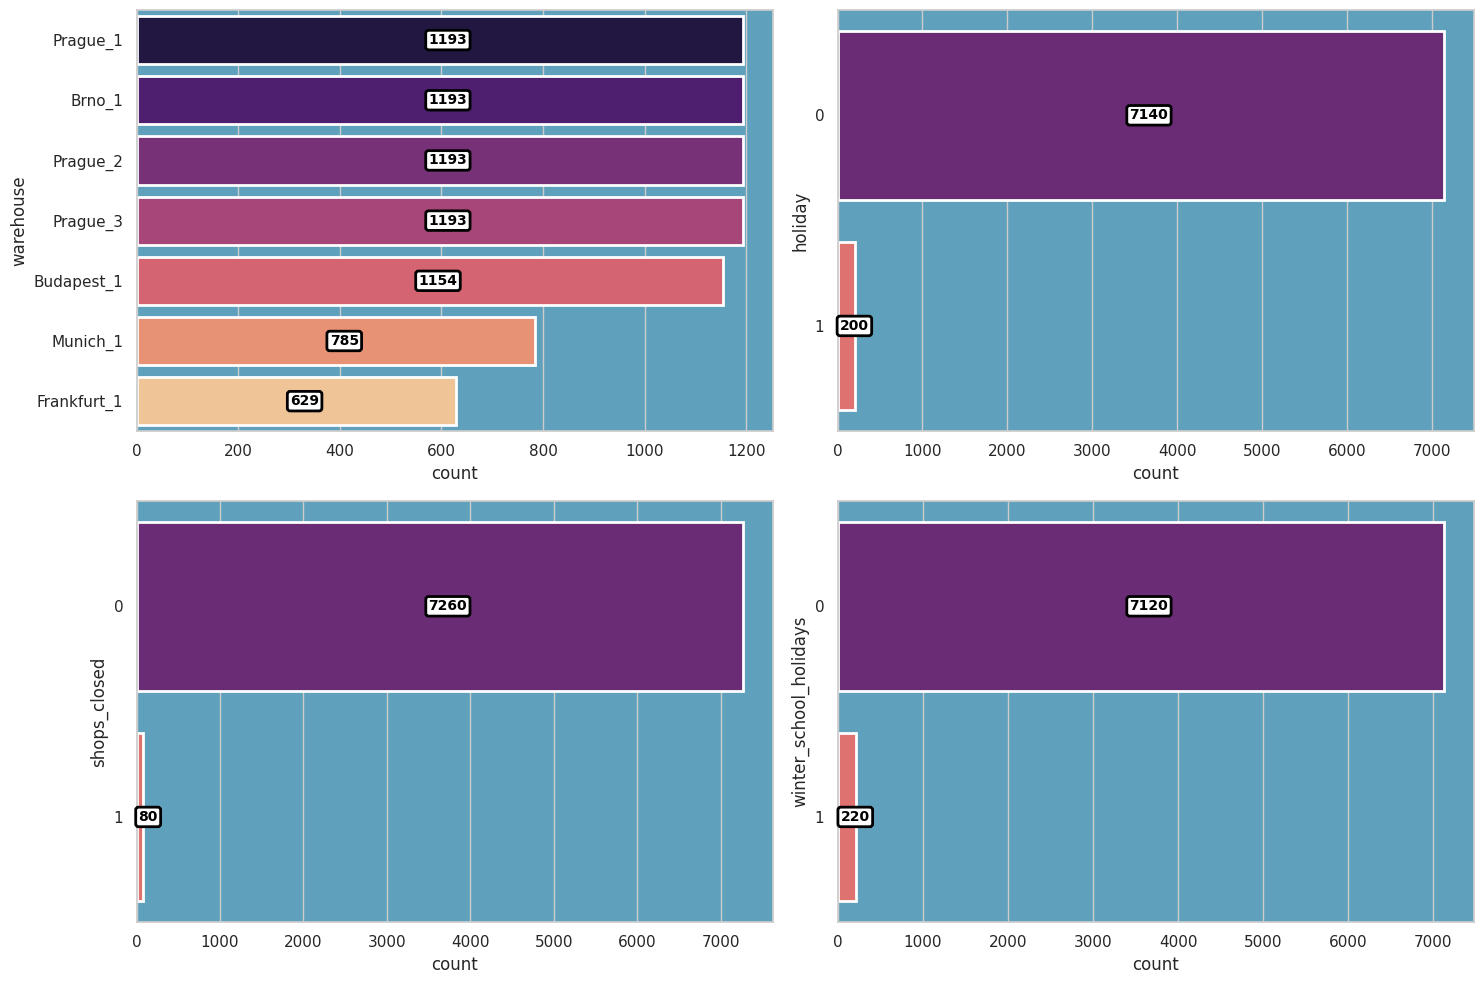

In [12]:
plot_low_value_count_columns(df_tr)

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ Encoding the columns˚ ༘ ೀ⋆｡ ˚</p> 

In [13]:
# Apply label encoding to 'warehouse' and 'holiday_name' columns Train Test
df_tr[['warehouse', 'holiday_name']] = df_tr[['warehouse', 'holiday_name']].apply(LabelEncoder().fit_transform)
df_ts[['warehouse', 'holiday_name']] = df_ts[['warehouse', 'holiday_name']].apply(LabelEncoder().fit_transform)

In [14]:
# feature engineering of date column
def cyclic_encode_date(df, date_col):

  # Extract year, month, day (assuming the format YYYY-MM-DD)
  df['year'] = pd.to_datetime(df[date_col]).dt.year
  df['month'] = pd.to_datetime(df[date_col]).dt.month / 12  # Normalize to 0-1 range
  df['day'] = pd.to_datetime(df[date_col]).dt.day / 31  # Normalize to 0-1 range (assuming 31 days)

  # Apply sine and cosine transformations
  df['year_sin'] = df['year'] * np.sin(2 * pi * df['year'])
  df['year_cos'] = df['year'] * np.cos(2 * pi * df['year'])
  df['month_sin'] = df['month'] * np.sin(2 * pi * df['month'])
  df['month_cos'] = df['month'] * np.cos(2 * pi * df['month'])
  df['day_sin'] = df['day'] * np.sin(2 * pi * df['day'])
  df['day_cos'] = df['day'] * np.cos(2 * pi * df['day'])

  return df

# Apply cyclic encoding to your DataFrame
df_tr = cyclic_encode_date(df_tr,'date')
df_ts = cyclic_encode_date(df_ts,'date')

In [15]:
# Removing Date From Train and Test
df_tr.drop('date', axis=1,inplace=True)
df_ts.drop('date', axis=1,inplace=True)

# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ Machine Learning ˚ ༘ ೀ⋆｡ ˚</p> 

In [16]:
# Spliting the data into features and target
X = df_tr.drop('orders', axis=1)
y = df_tr['orders']

In [17]:
# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the best parameters
best_params = {
    'n_estimators': 703,
    'learning_rate': 0.06814945127794421,
    'max_depth': 7,
    'reg_alpha': 0.07569481465417208,
    'reg_lambda': 2.1073371397761793,
    'num_leaves': 28,
    'subsample': 0.8680610615626715,
    'colsample_bytree': 0.893976646492343,
    'min_child_weight': 14,
    'min_split_gain': 0.7643791668215504,
    'subsample_freq': 2,
    'min_child_samples': 18,
    'device': 'gpu',  # Enable GPU support
    'gpu_platform_id': 0,  # Adjust if needed
    'gpu_device_id': 0,    # Adjust if needed
    'verbose': -1  # Suppress LightGBM output
}

# Train the model
model = LGBMRegressor(**best_params, random_state=42)
model.fit(X_train, y_train)

# Predict on the validation set
y_pred = model.predict(X_val)

# Calculate Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(y_val, y_pred)

print("Mean Absolute Percentage Error (MAPE):", mape)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Mean Absolute Percentage Error (MAPE): 0.05854326221958532


# <p style="font-family: 'Amiri'; font-size: 3rem; color: yellow; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #5fa1bc; padding: 20px; border-radius: 20px; border: 7px solid yellow; width:95%">˚ ༘ ೀ⋆｡ Thanks Alot For Reading I am WORKING ON 2ND version to get higher accuracy i will share that soon :)  ༘ ೀ⋆｡ ˚</p>